# Sprint 1 — Mushroom Dataset Exploration & Understanding

## Objective

Before building any deep learning model, it is essential to understand the dataset.

This notebook performs a comprehensive exploratory analysis of the Mushroom Species dataset.

The goals are:

- Understand the dataset structure
- Validate image paths
- Analyze class distribution
- Measure dataset balance
- Analyze image resolutions
- Detect corrupted or missing images
- Perform initial quality assessment

The observations obtained from this notebook will guide preprocessing strategies, model selection, augmentation policies and future experiments.

## 2. Imports

In [1]:
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd

from PIL import Image

import matplotlib.pyplot as plt

plt.style.use("ggplot")

## 3. Dataset Configuration

In [2]:
DATASET_ROOT = Path("datasets/extracted/mushroom")

TRAIN_CSV = DATASET_ROOT / "train.csv"
VAL_CSV = DATASET_ROOT / "val.csv"
TEST_CSV = DATASET_ROOT / "test.csv"

IMAGE_ROOT = DATASET_ROOT / "merged_dataset"

## 4. Load Dataset

### Dataset Loading

The predefined CSV files are loaded into memory.

These CSV files define the official train, validation and test splits provided by the dataset creators.

In [3]:
train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)
test_df = pd.read_csv(TEST_CSV)

print(f"Train      : {train_df.shape}")
print(f"Validation : {val_df.shape}")
print(f"Test       : {test_df.shape}")
train_df.head()

Train      : (689520, 2)
Validation : (15616, 2)
Test       : (15614, 2)


,image_path,label
0,/kaggle/working/merged_dataset/Lycoperdon perl...,Lycoperdon perlatum
1,/kaggle/working/merged_dataset/Chlorociboria a...,Chlorociboria aeruginascens
2,/kaggle/working/merged_dataset/Amanita muscari...,Amanita muscaria
3,/kaggle/working/merged_dataset/Xanthoria parie...,Xanthoria parietina
4,/kaggle/working/merged_dataset/Coprinellus mic...,Coprinellus micaceus


## 5. Dataset Overview

This section summarizes the overall size of the dataset and the number of unique mushroom species.

In [4]:
total_images = len(train_df) + len(val_df) + len(test_df)

num_classes = train_df["label"].nunique()

print(f"Total Images : {total_images:,}")
print(f"Number of Classes : {num_classes}")

Total Images : 720,750
Number of Classes : 169


## 6. Dataset Statistics

We compute descriptive statistics to understand how images are distributed among species.

In [5]:
class_counts = train_df["label"].value_counts()

display(class_counts.describe())
print("Minimum :", class_counts.min())
print("Maximum :", class_counts.max())
print("Mean :", class_counts.mean())
print("Median :", class_counts.median())
print("Std :", class_counts.std())

count     169.0
mean     4080.0
std         0.0
min      4080.0
25%      4080.0
50%      4080.0
75%      4080.0
max      4080.0
Name: count, dtype: float64

Minimum : 4080
Maximum : 4080
Mean : 4080.0
Median : 4080.0
Std : 0.0


## 7. Class Distribution

A balanced class distribution generally leads to more stable training and unbiased evaluation.

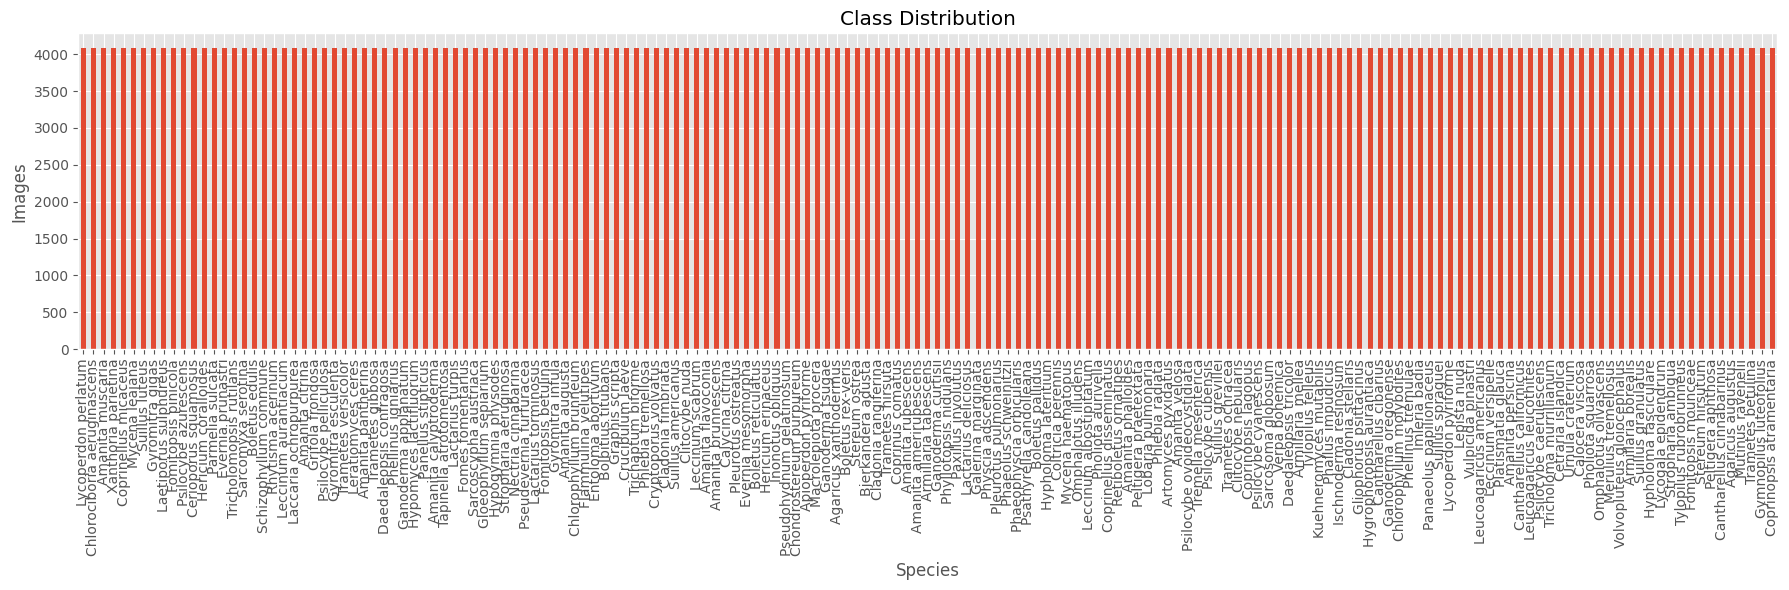

label
Lycoperdon perlatum            4080
Chlorociboria aeruginascens    4080
Amanita muscaria               4080
Xanthoria parietina            4080
Coprinellus micaceus           4080
Mycena leaiana                 4080
Suillus luteus                 4080
Gyromitra gigas                4080
Laetiporus sulphureus          4080
Fomitopsis pinicola            4080
Name: count, dtype: int64

label
Tylopilus rubrobrunneus      4080
Fomitopsis mounceae          4080
Stereum hirsutum             4080
Peltigera aphthosa           4080
Cantharellus cinnabarinus    4080
Agaricus augustus            4080
Mutinus ravenelii            4080
Trametes betulina            4080
Gymnopilus luteofolius       4080
Coprinopsis atramentaria     4080
Name: count, dtype: int64

In [6]:
plt.figure(figsize=(18,6))

class_counts.plot(kind="bar")

plt.xlabel("Species")
plt.ylabel("Images")
plt.title("Class Distribution")

plt.tight_layout()

plt.show()
display(class_counts.head(10))
display(class_counts.tail(10))

## 8. Image Path Validation

The dataset was originally prepared inside Kaggle.

Therefore, image paths stored inside the CSV files must be converted into local project paths before training.
We'll do a small piece of path engineering here first.

In [7]:
train_df["local_path"] = train_df["image_path"].str.replace(
    "/kaggle/working/merged_dataset",
    str(IMAGE_ROOT),
    regex=False,
)

val_df["local_path"] = val_df["image_path"].str.replace(
    "/kaggle/working/merged_dataset",
    str(IMAGE_ROOT),
    regex=False,
)

test_df["local_path"] = test_df["image_path"].str.replace(
    "/kaggle/working/merged_dataset",
    str(IMAGE_ROOT),
    regex=False,
)

print("Let's check.")

train_df[["image_path","local_path"]].head()

print("Do the files actually exist?")

exists = train_df["local_path"].apply(lambda x: Path(x).exists())

print(exists.value_counts())

Let's check.
Do the files actually exist?


local_path
True    689520
Name: count, dtype: int64


## 9. Image Resolution Analysis

Image size analysis helps determine an appropriate preprocessing strategy and model input resolution.

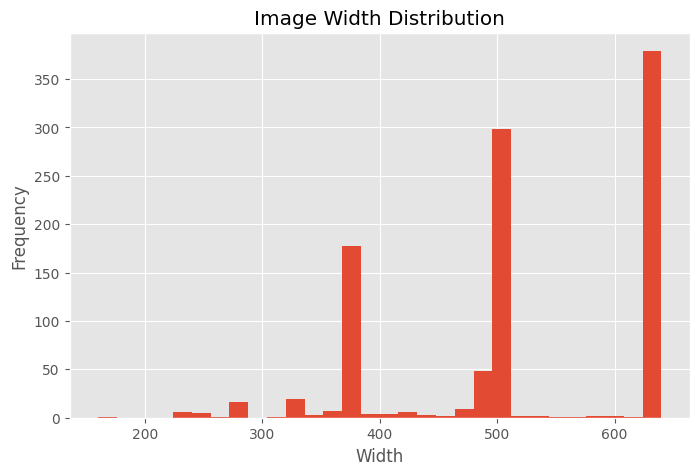

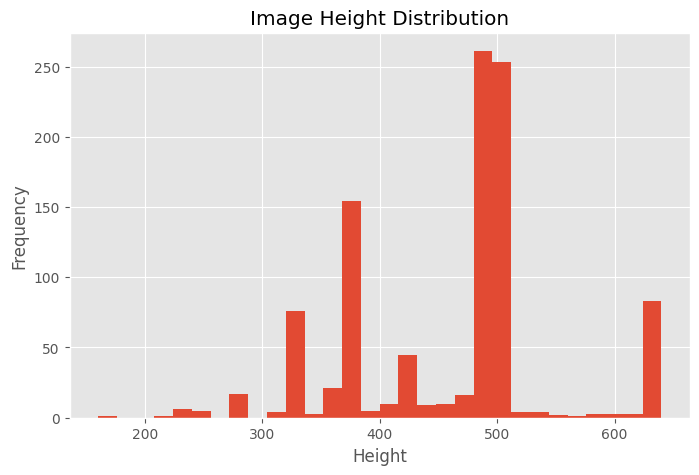

Average Width : 517.159
Average Height : 458.129


In [8]:
sizes = []

sample_paths = random.sample(train_df["local_path"].tolist(), 1000)

for path in sample_paths:
    img = Image.open(path)
    sizes.append(img.size)
widths = [w for w,h in sizes]
heights = [h for w,h in sizes]
plt.figure(figsize=(8,5))

plt.hist(widths,bins=30)

plt.xlabel("Width")

plt.ylabel("Frequency")

plt.title("Image Width Distribution")

plt.show()
plt.figure(figsize=(8,5))

plt.hist(heights,bins=30)

plt.xlabel("Height")

plt.ylabel("Frequency")

plt.title("Image Height Distribution")

plt.show()
print("Average Width :",np.mean(widths))
print("Average Height :",np.mean(heights))

## 10. Sample Visualization

Random visual inspection helps identify background complexity, image quality and fine-grained similarities between species.

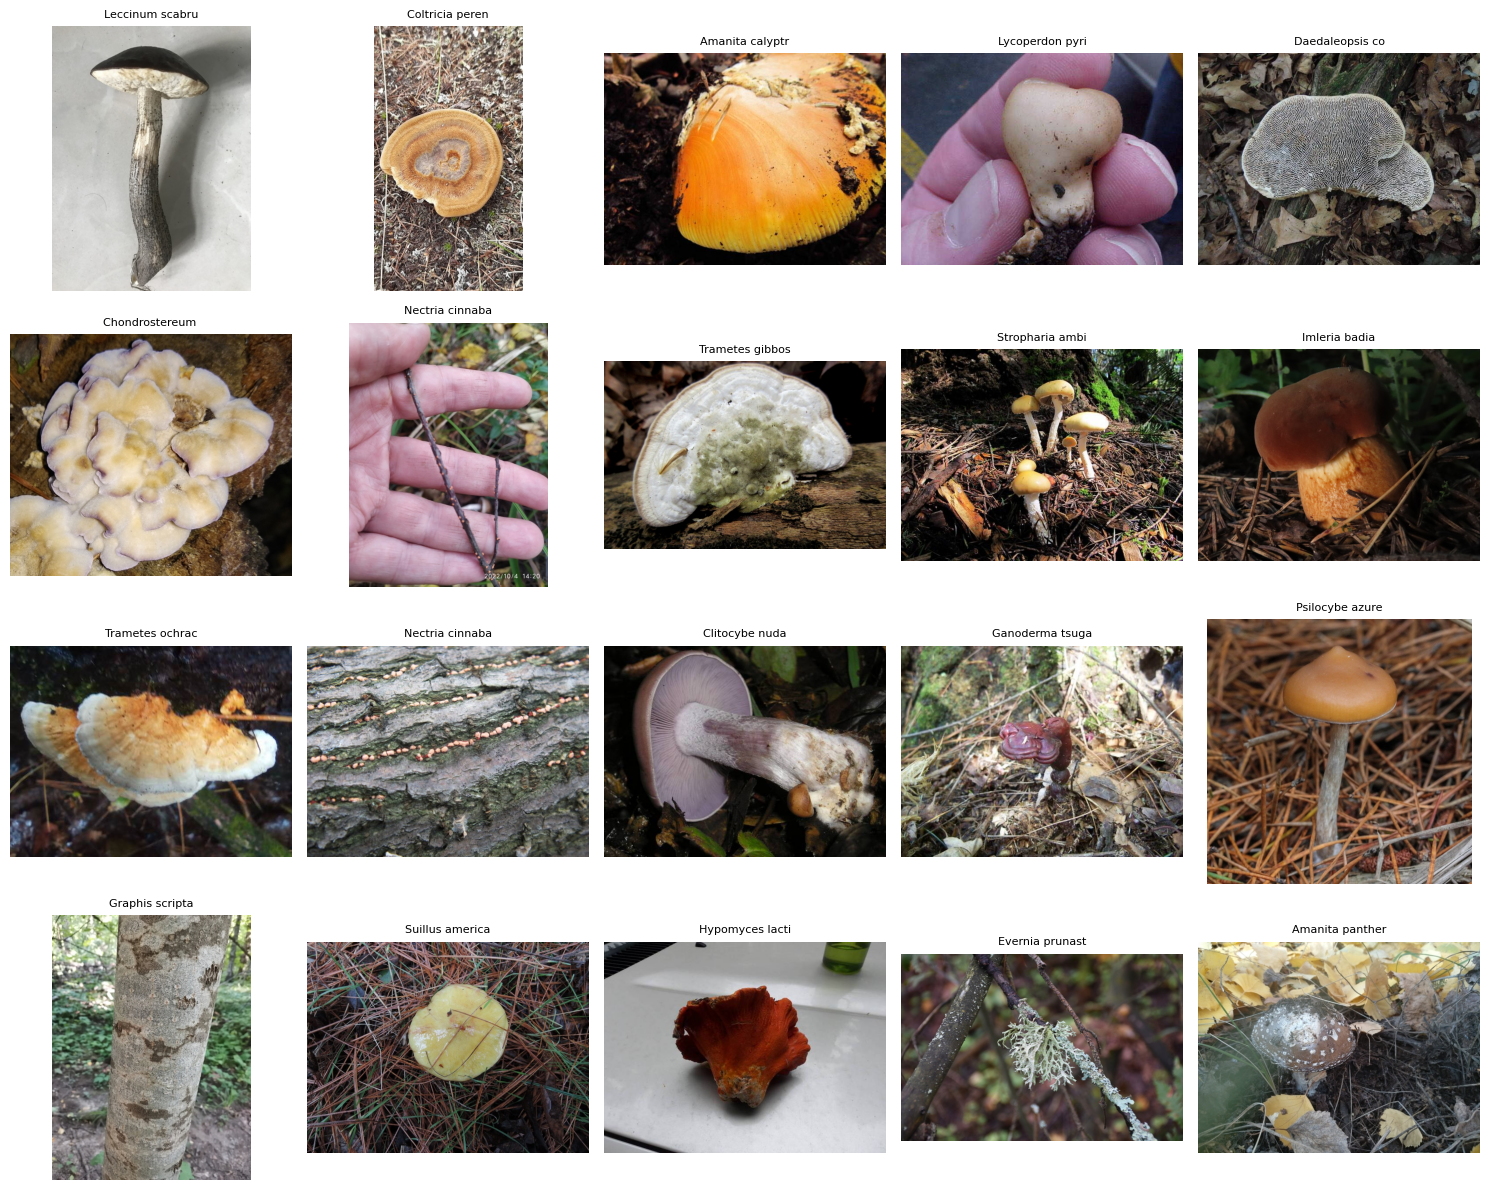

In [9]:
fig,axes = plt.subplots(4,5,figsize=(15,12))

samples=train_df.sample(20)

for ax,(_,row) in zip(axes.flatten(),samples.iterrows()):

    img=Image.open(row["local_path"])

    ax.imshow(img)

    ax.set_title(row["label"][:15],fontsize=8)

    ax.axis("off")

plt.tight_layout()

plt.show()

## 11. Dataset Integrity Checks

Before model training, we verify that all referenced images exist and can be opened successfully.

In [10]:
broken=[]

for path in random.sample(train_df["local_path"].tolist(),3000):

    try:
        Image.open(path)

    except Exception:

        broken.append(path)

print("Broken Images :",len(broken))

print("Are there any missing files?")

missing=[]

for path in train_df["local_path"]:

    if not Path(path).exists():

        missing.append(path)

print("Missing Files :",len(missing))

Broken Images : 0
Are there any missing files?


Missing Files : 0


## 12. Initial Findings

### Overall size

720,750 images in total, 169 species. Train/Val/Test: 689,520 / 15,616 / 15,614 —
roughly 95.6% / 2.2% / 2.2%. The val/test share is on the low side, but with
~90 samples per class in val (across 169 classes) it's probably sufficient.

### Most striking finding: the class distribution is perfectly balanced

`class_counts.describe()` shows `std = 0.0`, `min = max = mean = 4080` — every
single class has exactly 4080 images. This is something you almost never see
in a naturally collected dataset, which strongly suggests this Kaggle dataset
was already balanced via upsampling/downsampling (possibly duplicated through
augmentation).

Consequence: we don't need to worry about class imbalance — `class_weight` or
`WeightedRandomSampler` are unnecessary for this dataset.

**Open question (to resolve in Sprint 2):** is all of this 4080 made up of
original photos, or are some of them already augmented copies? If they're
augmented, our own augmentation pipeline needs to stay deliberately light —
otherwise we risk "augmenting an augmentation," adding noise instead of real
diversity.

### Path/file integrity — clean

The `local_path` conversion worked without issues: all 689,520 rows exist
(`True`). Across a 3,000-image sample: Broken Images: 0, Missing Files: 0.
Data is fully accessible — no blockers moving into Sprint 2.

### Image sizes — not standardized, needs attention

Width/height histograms don't converge on a single peak; they cluster around
a few distinct values (roughly 375, 500, 625). This suggests the images don't
come from original, untouched photos, but from sources that were already
resized to a handful of fixed sizes.

Practical implication: we need to settle on a `Resize` + `CenterCrop` (or
`RandomResizedCrop`) strategy in Sprint 2 — pick a single target resolution
for the model input (e.g. 224x224 or 384x384, depending on the chosen
architecture) and normalize everything to it.

### Visual inspection (Sample Visualization)

The 20 sampled images show high background diversity (soil, wood, grass,
hand-held, moss). That's a good thing — it forces the model to focus on the
species rather than the background — and it also gives us a solid reason to
test Grad-CAM explainability later.

Some species look visually very close to each other (e.g. different
Agaricus/Amanita species) — confirming why this is a fine-grained
classification problem; the model will need to pick up on fine details (cap
texture, stem structure).

## 13. Next Steps

Sprint 2 will focus on building a reusable and modular data pipeline.

Planned tasks include:

- Dataset class implementation
- Path management
- Configuration system
- Albumentations pipeline
- DataLoader
- Batch visualization
- Pipeline validation